# Exercise 2. Regression using MLP


In this exercise, there are two tasks  related to creating neural networks. The purpose of the tasks is to get acquainted with regression using neural networks, i.e. to create a model that predicts different order equations.

Both tasks have a conclusion cell, in which you can write down the summary how different configuration (epochs, number of hidden layers, number of nodes in hidden layers)  affects the results. 



## TASK 1

Purpose is to create neural network (MLP) to model the second order equation: 

$$ f(x) = x^2 + 3$$



In [16]:
# Generate dataset for the range [-3,3] with 200 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-3, 3, 200).reshape(-1, 1) # input dataset
y = X**2 + 3 # target dataset

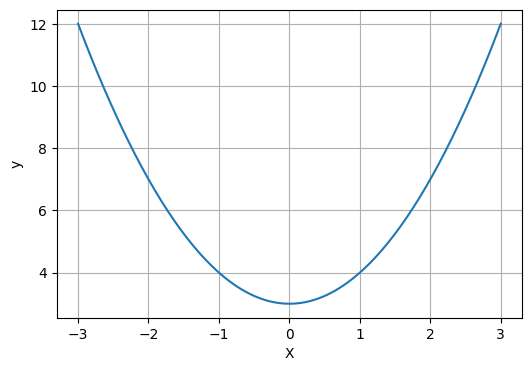

In [17]:
# Plot the sample
# Implementation comes to this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [7]:
# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [18]:
# Define neural network using Keras Function API
# Input layer = 1 node i.e. one feature, value of x-axis
# 1 hidden layer = 2-4 nodes.  Dense with 'relu' activation function in each hidden layer
# Second order equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

inputs = Input(shape=(1,))
hidden = Dense(4, activation='relu')(inputs)
outputs = Dense(1)(hidden)
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile with following parameters
# optimizer='adam', 
# loss='mean_squared_error',
# metrics=['mae'])
# Implementation comes this cell

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [77]:
# Fit model with 
# epochs: 100, 200, 300
# Implementation comes this cell

history = model.fit(X_train, y_train, epochs=300)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 61.7191 - mae: 6.9985  
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61.1951 - mae: 6.9665
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 60.6313 - mae: 6.9335
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 60.1121 - mae: 6.9015
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 59.5645 - mae: 6.8691
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 59.0356 - mae: 6.8368
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58.5309 - mae: 6.8057
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 58.0238 - mae: 6.7743
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 57.5240 - mae: 6.7428
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 57.0087 - mae: 6.7115
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 56.5226 - mae: 6.6809
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 56.0352 - mae: 6.6502
Epoch 13/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

In [78]:
# Evaluate()
# Implementation comes this cell
results = model.evaluate(X_test, y_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.2445 - mae: 2.5351 


In [79]:
# Predict using 30 sample from range [-2,3]
# Implementation comes this cell
X_new = np.linspace(-2, 3, 30).reshape(-1, 1)
y_new_predicted = model.predict(X_new)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


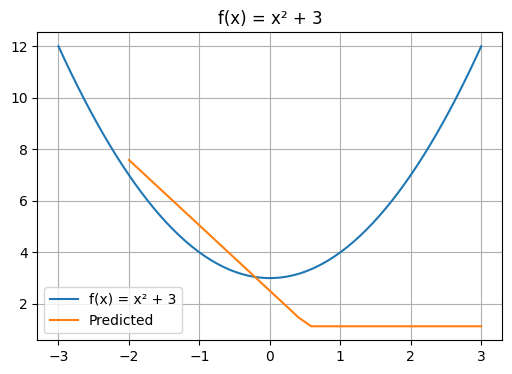

In [80]:
# Plot predicted values to same plot as the equation
# Implementation comes this cell
plt.figure(figsize=(6, 4))
plt.plot(X, y, label='f(x) = x² + 3')
plt.plot(X_new, y_new_predicted, label='Predicted')
plt.title("f(x) = x² + 3")
plt.grid(True)
plt.legend()
plt.show()


__Conclusion__

Short conclusion:
- How number of nodes in hidden layer affects the results?
- How the number of epochs affects the results?
- Etc.

## TASK 2

Purpose is to create neural network (MLP) to model the cubic (third) order equation: 

$$ f(x) = x^3 + 4x^2 - x + 2 $$


In [19]:
# Generate dataset for the range [-2,3] with 1000 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-3, 3, 1000).reshape(-1, 1) # input dataset
y = X**3 + 4*X**2 - X + 2 # target dataset

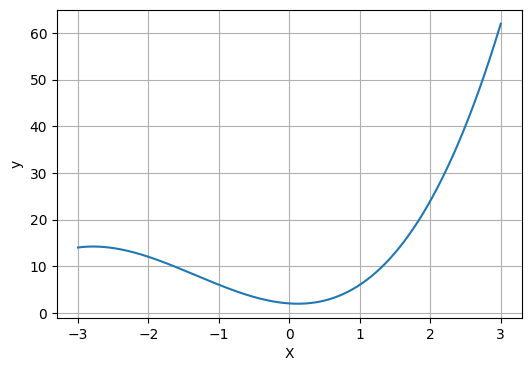

In [20]:
# Plot the sample
# Implementation comes to this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [21]:
# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [22]:
# Definen neyral network using Keras Function API
# Input layer = 1 node
# 1-2 hidden layer = 4-8 nodes. Dense with 'relu' activation function in each hidden layer
# Cubic equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()

inputs = Input(shape=(1,))
hidden1 = Dense(4, activation='relu')(inputs)
hidden2 = Dense(8, activation='relu')(hidden1)
outputs = Dense(1)(hidden2)
model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile with following parameters
# optimizer='adam', 
# loss='mean_squared_error',
# metrics=['mae'])
# Implementation comes this cell

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [ ]:
# Fit model with 
# epochs: 50, 100, 200
# Implementation comes this cell
history = model.fit(X_train, y_train, epochs=50)
#history = model.fit(X_train, y_train, epochs=100)
#history = model.fit(X_train, y_train, epochs=200)


In [ ]:
# Evaluate()
# Implementation comes this cell
results = model.evaluate(X_test, y_test)

In [ ]:
# Predict using 30 sample from range [-2,3]
# Implementation comes this cell

X_new = np.linspace(-2, 3, 30).reshape(-1, 1)
y_new_predicted = model.predict(X_new)

In [ ]:
# Plot predicted values to same plot as the equation
# Implementation comes this cell
plt.figure(figsize=(6, 4))
plt.plot(X, y, label='f(x) = x² + 3')
plt.plot(X_new, y_new_predicted, label='Predicted')
plt.title("f(x) = x² + 3")
plt.grid(True)
plt.legend()
plt.show()

__Conclusion__

__NOTE: Conclusion is one evaluation criterion for the exercise, so pay attention to writing this__

Write conclusion:
- How number of nodes in hidden layer affects the results?
- How the number of epochs affects the results?
- What you learn in this exercise?
- Did you have difficulties in the exercise?
To be honest I am not from ML backgroud and at times its getting difficult to understand nuances of NN and different terms.
- Etc.